In [28]:
# This notebook presents the final exploratory data analysis
# used to understand cyber-physical disturbances in the dataset.
# Additional exploratory work is available in 01_EDA_detailed.ipynb.

In [29]:
# =====================================
# Helper Functions for Dataset Exploration
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import f_classif, mutual_info_classif
import umap
from pandas.plotting import parallel_coordinates

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

print("import succussefully")

# ============================================================
# Smart Bar Label Function
# ============================================================

def add_bar_labels(ax, total):

    max_height = max(p.get_height() for p in ax.patches)

    for p in ax.patches:

        count = int(p.get_height())
        percentage = 100 * count / total

        if p.get_height() < 0.2 * max_height:

            ax.annotate(
                f"{count}\n({percentage:.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                color="black",
                fontsize=14,
                fontweight="bold"
            )

        else:

            ax.annotate(
                f"{count}\n({percentage:.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height()/2),
                ha="center",
                va="center",
                color="white",
                fontsize=16,
                fontweight="bold"
            )

import succussefully


In [30]:
# ============================================================
# Load RAW datasets (for EDA)
# ============================================================

binary_df = pd.read_csv("../data/merged/binary_dataset.csv")
three_df = pd.read_csv("../data/merged/three_class_dataset.csv")
multi_df = pd.read_csv("../data/merged/multi_class_dataset.csv")

# Clean column names
for df in [binary_df, three_df, multi_df]:
    df.columns = df.columns.str.strip()

print("Datasets loaded successfully")
print("Binary dataset shape:", binary_df.shape)
print("Three-class dataset shape:", three_df.shape)
print("Multi-class dataset shape:", multi_df.shape)

Datasets loaded successfully
Binary dataset shape: (78377, 129)
Three-class dataset shape: (78377, 129)
Multi-class dataset shape: (78377, 129)


In [41]:
# -------------------------------
# 0. LOOKUP Dictionary
# -------------------------------
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}

DI_NAMES = {
    7: "DI: Fault 10–19% L1",
    8: "DI: Fault 20–79% L1",
    9: "DI: Fault 80–90% L1",
    10: "DI: Fault 10–19% L2",
    11: "DI: Fault 20–79% L2",
    12: "DI: Fault 80–90% L2"
}

RT_NAMES = {
    15: "Remote Trip: Cmd R1",
    16: "Remote Trip: Cmd R2",
    17: "Remote Trip: Cmd R3",
    18: "Remote Trip: Cmd R4",
    19: "Remote Trip: Cmd R1 & R2",
    20: "Remote Trip: Cmd R3 & R4"
}

RSC_NAMES = {
    21: "RSC: L1 R1 Disabled (10–19%)",
    22: "RSC: L1 R1 Disabled (20–90%)",
    23: "RSC: L1 R2 Disabled (10–49%)", 
    24: "RSC: L1 R2 Disabled (50–79%)",
    25: "RSC: L1 R2 Disabled (80–90%)",
    26: "RSC: L2 R3 Disabled (10–19%)",
    27: "RSC: L2 R3 Disabled (20–49%)",
    28: "RSC: L2 R3 Disabled (50–90%)",
    29: "RSC: L2 R4 Disabled (10–79%)",
    30: "RSC: L2 R4 Disabled (80–90%)",
    35: "RSC: L1 R1&R2 Disabled (10–49%)",
    36: "RSC: L1 R1&R2 Disabled (50–90%)",
    37: "RSC: L1 R3&R4 Disabled (10–49%)",
    38: "RSC: L1 R3&R4 Disabled (50–90%)",
    39: "RSC: L1 Maint R1&R2 Disabled",
    40: "RSC: L2 Maint R3&R4 Disabled"
}

SCENARIO_SHORT = {

# Natural Faults
1:  "F L1 10–19%",
2:  "F L1 20–79%",
3:  "F L1 80–90%",
4:  "F L2 10–19%",
5:  "F L2 20–79%",
6:  "F L2 80–90%",

# Data Injection
7:  "DI L1 10–19%",
8:  "DI L1 20–79%",
9:  "DI L1 80–90%",
10: "DI L2 10–19%",
11: "DI L2 20–79%",
12: "DI L2 80–90%",

# Maintenance
13: "Maint L1",
14: "Maint L2",

# Remote Tripping
15: "RT R1",
16: "RT R2",
17: "RT R3",
18: "RT R4",
19: "RT R1&R2",
20: "RT R3&R4",

# Relay Setting Change
21: "RSC L1 R1 10–19%",
22: "RSC L1 R1 20–90%",
23: "RSC L1 R2 10–49%",
24: "RSC L1 R2 50–79%",
25: "RSC L1 R2 80–90%",
26: "RSC L2 R3 10–19%",
27: "RSC L2 R3 20–49%",
28: "RSC L2 R3 50–90%",
29: "RSC L2 R4 10–79%",
30: "RSC L2 R4 80–90%",

# Dual Relay Setting Change
35: "RSC L1 R1&R2",
36: "RSC L1 R1&R2",
37: "RSC L2 R3&R4",
38: "RSC L2 R3&R4",

# Maintenance + Relay Setting Change
39: "Maint+RSC L1 R1&R2",
40: "Maint+RSC L2 R3&R4",

# Normal
41: "Normal"
}

In [42]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("\n==============================")
print("DATASET SUMMARY")
print("==============================")

summary_table = pd.DataFrame({

    "Dataset": ["Binary", "Three-Class", "Multi-Class"],

    "Samples": [
        binary_df.shape[0],
        three_df.shape[0],
        multi_df.shape[0]
    ],

    "Features": [
        binary_df.shape[1] - 1,
        three_df.shape[1] - 1,
        multi_df.shape[1] - 1
    ],

    "Classes": [
        binary_df["marker"].nunique(),
        three_df["marker"].nunique(),
        multi_df["marker"].nunique()
    ],

    "Target": [
        "marker",
        "marker",
        "marker"
    ],

    "Scenario Coverage": [
        "Attack vs Non-Attack",
        "Attack / Natural / Normal",
        "Available scenario set (37 / 41)"
    ],

    "Purpose": [
        "Binary reference dataset",
        "Operational context reference",
        "Primary modelling dataset"
    ]

})

display(summary_table)


# ------------------------------------------------------------
# Scenario Verification
# ------------------------------------------------------------

print("\n==============================")
print("SCENARIO VERIFICATION")
print("==============================")

scenario_ids = sorted(multi_df["marker"].unique().tolist())

print("Scenario IDs present:")
print(scenario_ids)

print("\nTotal scenarios detected:", len(scenario_ids))


print("\nTop Scenario Frequencies")

display(
    multi_df["marker"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)


# ------------------------------------------------------------
# Dataset Preview
# ------------------------------------------------------------

print("\n==============================")
print("DATASET PREVIEW")
print("==============================")

display(multi_df.head())


# ------------------------------------------------------------
# Dataset Structure
# ------------------------------------------------------------

print("\n==============================")
print("DATASET STRUCTURE")
print("==============================")

multi_df.info()


# ------------------------------------------------------------
# Missing Values Check
# ------------------------------------------------------------

print("\n==============================")
print("MISSING VALUES CHECK")
print("==============================")

missing = multi_df.isna().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values detected.")
else:
    display(missing.sort_values(ascending=False))


# ------------------------------------------------------------
# Infinite Values Check
# ------------------------------------------------------------

print("\n==============================")
print("INFINITE VALUES CHECK")
print("==============================")

inf_values = np.isinf(
    multi_df.select_dtypes(include=np.number)
).sum().sum()

print("Total infinite values:", inf_values)


DATASET SUMMARY


,Dataset,Samples,Features,Classes,Target,Scenario Coverage,Purpose
0,Binary,78377,129,2,marker,Attack vs Non-Attack,Binary reference dataset
1,Three-Class,78377,129,3,marker,Attack / Natural / Normal,Operational context reference
2,Multi-Class,78377,131,37,marker,Available scenario set (37 / 41),Primary modelling dataset



SCENARIO VERIFICATION
Scenario IDs present:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 35, 36, 37, 38, 39, 40, 41]

Total scenarios detected: 37

Top Scenario Frequencies


marker
36    4685
35    4487
41    4405
6     3485
5     3084
4     2968
37    2716
23    2635
25    2481
30    2368
Name: count, dtype: int64


DATASET PREVIEW


,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,...,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4,marker,target_3class,scenario_group,has_log
0,66.445916,133715.7489,-53.537176,133715.7489,-173.531727,133790.9687,63.896253,589.79731,-60.464236,622.57400,...,0.0,0.0,0.0,0.0,0.0,0.0,41,NoEvent,No Event (Normal Operation),0
1,59.908467,127622.9443,-60.068895,127597.8710,179.943125,127673.0908,55.089892,629.34907,-67.964254,654.06892,...,0.0,0.0,0.0,0.0,0.0,0.0,41,NoEvent,No Event (Normal Operation),0
2,58.630771,127296.9918,-61.346591,127271.9185,178.659700,127372.2116,52.987137,638.68768,-69.494051,658.09734,...,0.0,0.0,0.0,0.0,0.0,0.0,41,NoEvent,No Event (Normal Operation),0
3,62.996710,131534.3744,-56.980653,131509.3012,-176.969474,131609.5942,62.068518,448.25328,-61.237729,466.38117,...,0.0,0.0,0.0,0.0,0.0,0.0,41,NoEvent,No Event (Normal Operation),0
4,64.314513,131333.7883,-55.680039,131308.7150,-175.668860,131434.0813,62.979521,451.54926,-59.616259,466.38117,...,0.0,0.0,0.0,0.0,0.0,0.0,41,NoEvent,No Event (Normal Operation),0



DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78377 entries, 0 to 78376
Columns: 132 entries, R1-PA1:VH to has_log
dtypes: float64(128), int64(2), object(2)
memory usage: 78.9+ MB

MISSING VALUES CHECK
No missing values detected.

INFINITE VALUES CHECK
Total infinite values: 10906


Note on Scenario Count

Although the dataset documentation describes 41 event scenarios,
only 37 scenario labels appear in the released dataset files.
Scenarios 31–34 are not present in any dataset.

Therefore, the multi-class analysis uses the 37 available scenarios.

Dataset shape: (78377, 130)
Total NaN: 0
Total INF: 10906

Marker values present:
marker
Attack     55663
Natural    22714
Name: count, dtype: int64


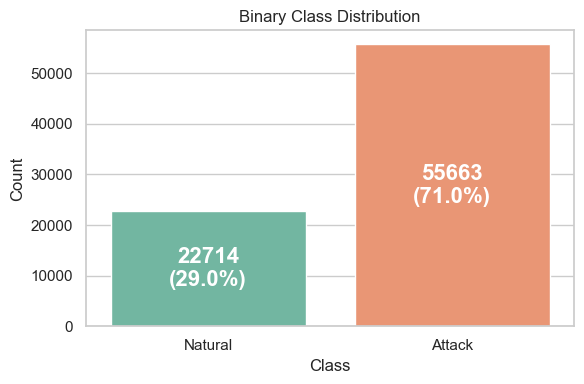


Top Binary Features:
['R2-PM1:V', 'R2-PM11:I', 'R3-PM11:I', 'R2-PM8:V', 'R3-PM8:V', 'R4-PM2:V', 'R2-PA6:IH']
Top feature for binary save


In [43]:
# ============================================================
# Binary Dataset Exploration (Reference)
# ============================================================

# ------------------------------------------------------------
# 1. Dataset Check
# ------------------------------------------------------------

binary_df.columns = binary_df.columns.str.strip()

print("Dataset shape:", binary_df.shape)

print("Total NaN:", binary_df.isna().sum().sum())

print(
    "Total INF:",
    np.isinf(
        binary_df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nMarker values present:")
print(binary_df["marker"].value_counts())


# ------------------------------------------------------------
# 2. Class Distribution
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="marker",
    data=binary_df,
    palette="Set2",
    order=["Natural","Attack"]
)

plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

total = len(binary_df)

add_bar_labels(ax, total)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Top Features (Correlation with Attack label)
# ------------------------------------------------------------

binary_df["target_num"] = binary_df["marker"].astype("category").cat.codes

numeric_cols = binary_df.select_dtypes(include="number").columns

numeric_cols = [
    c for c in numeric_cols
    if c not in ["target_num","marker","Scenario_ID"]
    and "log" not in c.lower()
]

corr_target = (
    binary_df[numeric_cols]
    .corrwith(binary_df["target_num"])
    .abs()
    .sort_values(ascending=False)
)

top7_binary = corr_target.head(7)

print("\nTop Binary Features:")
print(top7_binary.index.tolist())


# ------------------------------------------------------------
# Save Top Features
# ------------------------------------------------------------

top7_binary.to_json(
    "../data/features/binary_top_features.json",
    indent=4
)
print('Top feature for binary save')

Dataset shape: (78377, 130)
Total NaN: 0
Total INF: 10906

Marker values present:
marker
Attack      55663
Natural     18309
NoEvents     4405
Name: count, dtype: int64


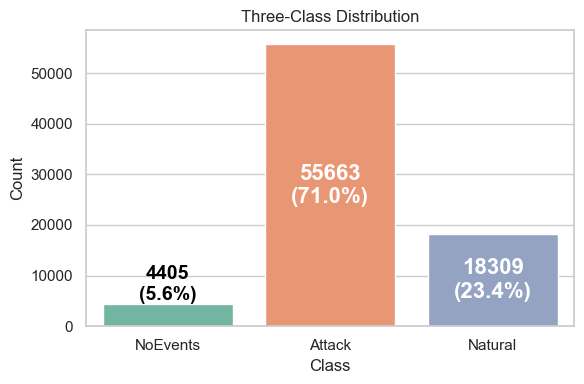


Top Three-Class Features:
['R2-PM1:V', 'R2-PM11:I', 'R3-PM11:I', 'R2-PM12:I', 'R1-PM11:I', 'R3-PM1:V', 'R2-PM7:V']
Top features for three-class saved


In [44]:
# ============================================================
# Three-Class Dataset Exploration (Reference)
# ============================================================

# ------------------------------------------------------------
# 1. Dataset Check
# ------------------------------------------------------------

three_df.columns = three_df.columns.str.strip()

print("Dataset shape:", three_df.shape)

print("Total NaN:", three_df.isna().sum().sum())

print(
    "Total INF:",
    np.isinf(
        three_df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nMarker values present:")
print(three_df["marker"].value_counts())


# ------------------------------------------------------------
# 2. Class Distribution
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="marker",
    data=three_df,
    palette="Set2",
    order=["NoEvents", "Attack", "Natural"]
)

plt.title("Three-Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

total = len(three_df)

add_bar_labels(ax, total)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Top Features (Correlation with class label)
# ------------------------------------------------------------

three_df["target_num"] = three_df["marker"].astype("category").cat.codes

numeric_cols = three_df.select_dtypes(include="number").columns

numeric_cols = [
    c for c in numeric_cols
    if c not in ["target_num","marker","Scenario_ID"]
    and "log" not in c.lower()
]

corr_target = (
    three_df[numeric_cols]
    .corrwith(three_df["target_num"])
    .abs()
    .sort_values(ascending=False)
)

top7_three = corr_target.head(7)

print("\nTop Three-Class Features:")
print(top7_three.index.tolist())


# ------------------------------------------------------------
# Save Top Features
# ------------------------------------------------------------

top7_three.to_json(
    "../data/features/three_top_features.json",
    indent=4
)

print("Top features for three-class saved")

In [45]:
# ============================================================
# Multi-Class Dataset Exploration (Main Dataset)
# ============================================================


# ------------------------------------------------------------
# Dataset Check
# ------------------------------------------------------------

multi_df.columns = multi_df.columns.str.strip()

print("Dataset shape:", multi_df.shape)

print("Total NaN:", multi_df.isna().sum().sum())

print(
    "Total INF:",
    np.isinf(
        multi_df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nMarker values present:")
print(sorted(int(x) for x in multi_df["marker"].unique()))


# ------------------------------------------------------------
# Create 3-Class Target
# ------------------------------------------------------------

multi_df["target_3class"] = "Unknown"

natural = list(range(1,7)) + [13,14]
noevent = [41]

attack = [
    s for s in multi_df["marker"].unique()
    if s not in natural + noevent
]

multi_df.loc[multi_df["marker"].isin(natural), "target_3class"] = "Natural"
multi_df.loc[multi_df["marker"].isin(noevent), "target_3class"] = "NoEvent"
multi_df.loc[multi_df["marker"].isin(attack), "target_3class"] = "Attack"

# ------------------------------------------------------------
# Scenario Group Mapping
# ------------------------------------------------------------

def map_six_groups(s):

    s = int(s)

    if 1 <= s <= 6:
        return "Short-Circuit Fault (Natural)"

    elif 7 <= s <= 12:
        return "Data Injection Attack"

    elif 13 <= s <= 14:
        return "Line Maintenance (Natural)"

    elif 15 <= s <= 20:
        return "Remote Tripping Attack"

    elif 21 <= s <= 30 or 35 <= s <= 40:
        return "Relay Setting Change Attack"

    elif s == 41:
        return "No Event (Normal Operation)"

    else:
        return "Unknown"


multi_df["scenario_group"] = multi_df["marker"].apply(map_six_groups)


# ------------------------------------------------------------
# Three-Class Distribution Table
# ------------------------------------------------------------

three_counts = multi_df["target_3class"].value_counts()

three_table = pd.DataFrame({
    "Count": three_counts,
    "Percentage (%)": (three_counts / three_counts.sum() * 100).round(2)
})

print("\nThree-Class Distribution")
display(three_table)


# ------------------------------------------------------------
# Scenario Group Distribution Table
# ------------------------------------------------------------

group_counts = multi_df["scenario_group"].value_counts()

group_table = pd.DataFrame({
    "Count": group_counts,
    "Percentage (%)": (group_counts / group_counts.sum() * 100).round(2)
})

print("\nScenario Group Distribution")
display(group_table)

Dataset shape: (78377, 132)
Total NaN: 0
Total INF: 10906

Marker values present:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 35, 36, 37, 38, 39, 40, 41]

Three-Class Distribution


,Count,Percentage (%)
target_3class,,
Attack,55663,71.02
Natural,18309,23.36
NoEvent,4405,5.62



Scenario Group Distribution


,Count,Percentage (%)
scenario_group,,
Relay Setting Change Attack,37344,47.65
Short-Circuit Fault (Natural),15000,19.14
Data Injection Attack,9582,12.23
Remote Tripping Attack,8737,11.15
No Event (Normal Operation),4405,5.62
Line Maintenance (Natural),3309,4.22


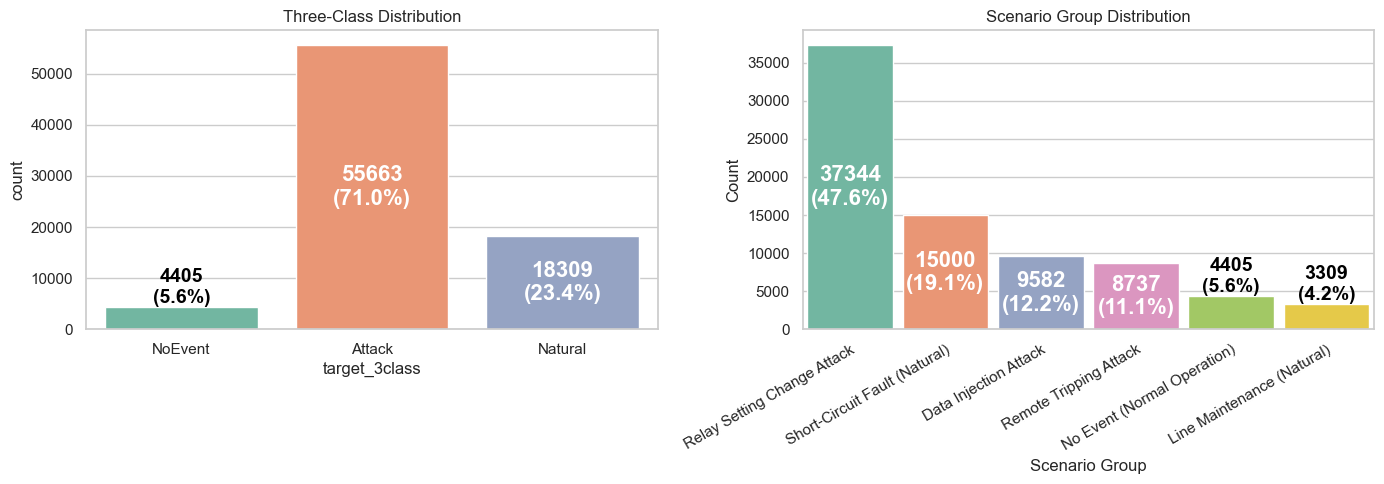

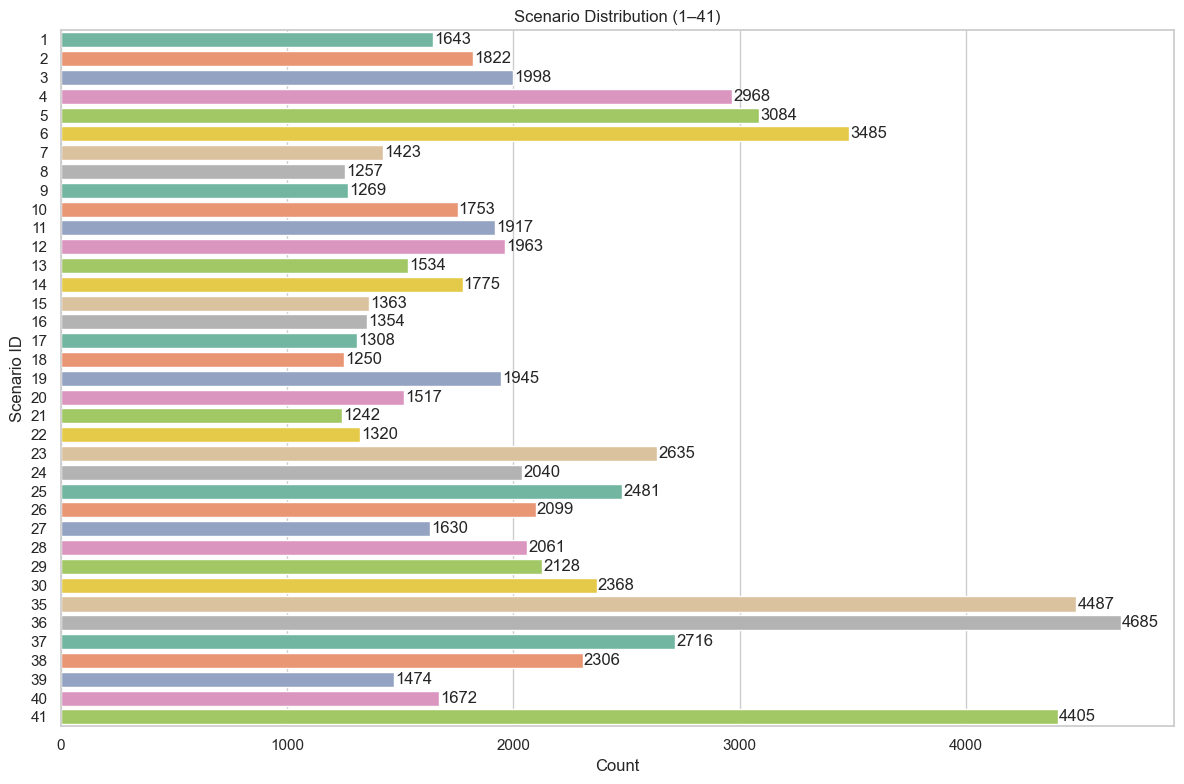

In [46]:
# ------------------------------------------------------------
# Side-by-Side Distribution Plots
# ------------------------------------------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))

# ------------------------------------------------------------
# 3-Class Distribution
# ------------------------------------------------------------

ax1 = sns.countplot(
    x="target_3class",
    data=multi_df,
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Three-Class Distribution")

add_bar_labels(ax1, len(multi_df))


# ------------------------------------------------------------
# Scenario Group Distribution
# ------------------------------------------------------------

group_order = multi_df["scenario_group"].value_counts().index

ax2 = sns.countplot(
    x="scenario_group",
    data=multi_df,
    palette="Set2",
    order=group_order,
    width=0.9,
    ax=axes[1]
)

axes[1].set_title("Scenario Group Distribution")
axes[1].set_xlabel("Scenario Group")
axes[1].set_ylabel("Count")

ax2.set_xticklabels(
    ax2.get_xticklabels(),
    rotation=30,
    ha="right",
    rotation_mode="anchor"
)

add_bar_labels(ax2, len(multi_df))


plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Raw Scenario Distribution (1–41)
# ------------------------------------------------------------

plt.close()   # important: reset previous subplot layout

scenario_counts = multi_df["marker"].value_counts().sort_index()

plt.figure(figsize=(12,8))

ax = sns.barplot(
    y=scenario_counts.index,
    x=scenario_counts.values,
    palette="Set2",
    orient="h"
)

for i, v in enumerate(scenario_counts.values):
    ax.text(v + 5, i, str(v), va="center")

plt.title("Scenario Distribution (1–41)")
plt.xlabel("Count")
plt.ylabel("Scenario ID")

plt.tight_layout()
plt.show()

104
['R1-PA1:VH', 'R1-PM1:V', 'R1-PA2:VH', 'R1-PM2:V', 'R1-PA3:VH', 'R1-PM3:V', 'R1-PA4:IH', 'R1-PM4:I', 'R1-PA5:IH', 'R1-PM5:I']
✅ Relay baseline saved
✅ PMU baseline saved
Relay signals used: 112


,R1,R2,R3,R4
marker,,,,
1,0.251947,0.249296,0.214471,0.177951
2,0.214245,0.226236,0.195804,0.171393
3,0.188687,0.218285,0.190260,0.158067
4,0.120864,0.144669,0.153313,0.235094
5,0.171184,0.181123,0.145278,0.215373


Voltage Mag 24
Voltage Angle 24
Current Mag 24
Current Angle 24
Frequency 4
ROCOF 4
PMU measurement signals: 104


,Voltage Mag,Voltage Angle,Current Mag,Current Angle,Frequency,ROCOF
marker,,,,,,
1,0.152052,0.096089,0.536543,0.154835,0.002932,0.059878
2,0.137478,0.084658,0.499856,0.144993,0.002293,0.041539
3,0.132989,0.071415,0.516360,0.100565,0.004609,0.013221
4,0.231085,0.074144,0.306145,0.106078,0.001822,0.018777
5,0.254870,0.126031,0.279104,0.129568,0.004066,0.028423


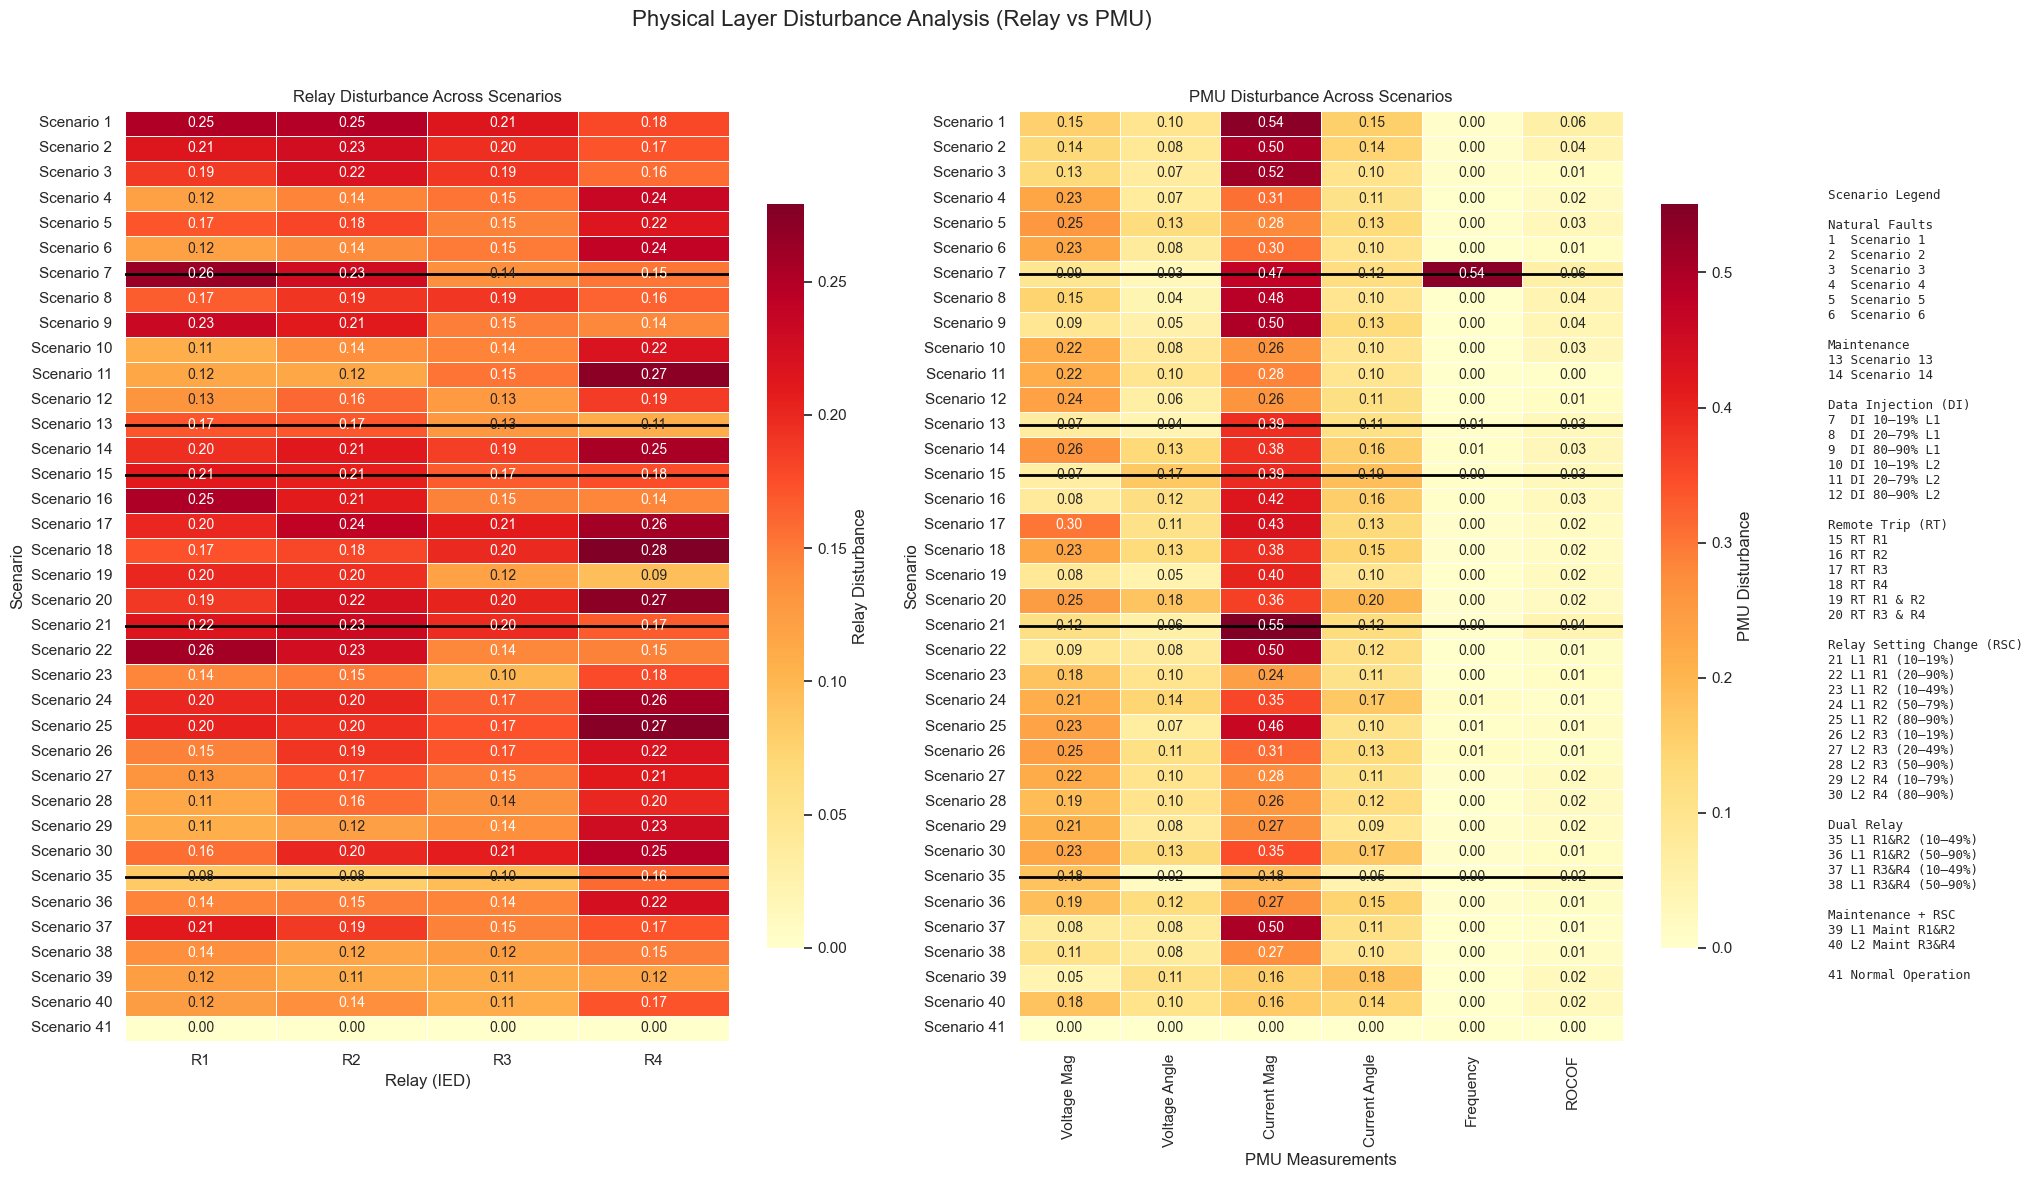

In [93]:
# ============================================================
# Physical Layer Disturbance Analysis (Relay vs PMU)
# ============================================================
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df = pd.read_csv("../data/merged/multi_class_dataset_clean_FULL.csv")

df.columns = df.columns.str.strip()

# ------------------------------------------------------------
# Scenario name lookup (optional but recommended)
# ------------------------------------------------------------
SCENARIO_LOOKUP = {
    i: f"Scenario {i}" for i in sorted(df["marker"].unique())
}

# ------------------------------------------------------------
# 1. Relay Features
# ------------------------------------------------------------

VALID_SUFFIXES = (
    ":V", ":I", ":VH", ":IH", ":Z", ":ZH", ":F", ":DF"
)

relay_groups = {
    "R1": [c for c in df.columns if c.startswith("R1") and c.endswith(VALID_SUFFIXES)],
    "R2": [c for c in df.columns if c.startswith("R2") and c.endswith(VALID_SUFFIXES)],
    "R3": [c for c in df.columns if c.startswith("R3") and c.endswith(VALID_SUFFIXES)],
    "R4": [c for c in df.columns if c.startswith("R4") and c.endswith(VALID_SUFFIXES)],
}

all_relay_features = sum(relay_groups.values(), [])

# ------------------------------------------------------------
# 2. PMU Measurement Features
# ------------------------------------------------------------

pmu_cols = [
    c for c in df.columns
    if any(c.endswith(s) for s in [":VH",":IH",":V",":I",":F",":DF"])
]

print(len(pmu_cols))
print(pmu_cols[:10])
# ------------------------------------------------------------
# 3. Standardize Signals
# ------------------------------------------------------------

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[all_relay_features + pmu_cols] = scaler.fit_transform(
    df[all_relay_features + pmu_cols]
)

# ------------------------------------------------------------
# 🔥 4. BASELINE COMPUTATION (IMPORTANT)
# ------------------------------------------------------------

os.makedirs("../data/baseline", exist_ok=True)

# Relay baseline (ALL features together)
relay_mean_all = df_scaled.groupby("marker")[all_relay_features].mean()
relay_baseline = relay_mean_all.loc[41]
relay_baseline.to_csv("../data/baseline/relay_baseline.csv")

print("✅ Relay baseline saved")

# PMU baseline
pmu_mean_all = df_scaled.groupby("marker")[pmu_cols].mean()
baseline_pmu = pmu_mean_all.loc[41]
baseline_pmu.to_csv("../data/baseline/pmu_baseline.csv")

print("✅ PMU baseline saved")

# ------------------------------------------------------------
# 5. Relay Disturbance Calculation
# ------------------------------------------------------------

relay_scenario = {}

for relay, cols in relay_groups.items():

    relay_mean = df_scaled.groupby("marker")[cols].mean()

    # safe baseline
    baseline = relay_mean.loc[41]

    relay_scenario[relay] = np.abs(
        relay_mean.subtract(baseline)
    ).mean(axis=1)

relay_disturbance = pd.DataFrame(relay_scenario).sort_index()

print("Relay signals used:", len(all_relay_features))
display(relay_disturbance.head())

# ------------------------------------------------------------
# PMU Disturbance Calculation (by measurement type)
# ------------------------------------------------------------

pmu_groups = {

    "Voltage Mag": [c for c in pmu_cols if c.endswith(":V")],
    "Voltage Angle": [c for c in pmu_cols if c.endswith(":VH")],

    "Current Mag": [c for c in pmu_cols if c.endswith(":I")],
    "Current Angle": [c for c in pmu_cols if c.endswith(":IH")],

    "Frequency": [c for c in pmu_cols if c.endswith(":F")],
    "ROCOF": [c for c in pmu_cols if c.endswith(":DF")]

}

pmu_mean_all = df_scaled.groupby("marker")[pmu_cols].mean()

baseline_pmu = pmu_mean_all.loc[41]

pmu_scenario = {}

for k, v in pmu_groups.items():
    print(k, len(v))
    
for signal, cols in pmu_groups.items():

    if len(cols) == 0:
        continue

    pmu_scenario[signal] = (
        (pmu_mean_all[cols] - baseline_pmu[cols])
        .abs()
        .mean(axis=1)
    )

pmu_disturbance = pd.DataFrame(pmu_scenario).sort_index()

print("PMU measurement signals:", len(pmu_cols))
display(pmu_disturbance.head())

# ------------------------------------------------------------
# 6. Map Scenario Names
# ------------------------------------------------------------

relay_disturbance.index = relay_disturbance.index.map(
    lambda x: SCENARIO_LOOKUP.get(x, f"Scenario {x}")
)

pmu_disturbance.index = pmu_disturbance.index.map(
    lambda x: SCENARIO_LOOKUP.get(x, f"Scenario {x}")
)

# ------------------------------------------------------------
# 7. Plot Heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(1,2, figsize=(18,12))

relay_vmax = relay_disturbance.values.max()
pmu_vmax = pmu_disturbance.values.max()

# ---------------- Relay Heatmap ----------------

sns.heatmap(
    relay_disturbance,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10},
    vmin=0,
    vmax=relay_vmax,
    robust=True,
    ax=axes[0],
    cbar_kws={"label":"Relay Disturbance", "shrink":0.8}
)

axes[0].set_title("Relay Disturbance Across Scenarios")
axes[0].set_xlabel("Relay (IED)")
axes[0].set_ylabel("Scenario")

# ---------------- PMU Heatmap ----------------

sns.heatmap(
    pmu_disturbance,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10},
    vmin=0,
    vmax=pmu_vmax,
    robust=True,
    ax=axes[1],
    cbar_kws={"label":"PMU Disturbance", "shrink":0.8}
)

axes[1].set_title("PMU Disturbance Across Scenarios")
axes[1].set_xlabel("PMU Measurements")
axes[1].set_ylabel("Scenario")

# ------------------------------------------------------------
# Scenario group separators
# ------------------------------------------------------------

for y in [6,12,14,20,30,40]:
    axes[0].axhline(y + 0.5, color="black", linewidth=2)
    axes[1].axhline(y + 0.5, color="black", linewidth=2)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.suptitle(
    "Physical Layer Disturbance Analysis (Relay vs PMU)",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.96])
# ------------------------------------------------------------
# Build legend automatically from dictionaries
# ------------------------------------------------------------

legend_lines = ["Scenario Legend\n"]

# Natural faults
legend_lines.append("Natural Faults")
for i in range(1,7):
    text = SCENARIO_LOOKUP[i]
    text = text.replace("Fault ", "").replace("(", "").replace(")", "")
    legend_lines.append(f"{i:<2} {text}")

legend_lines.append("\nMaintenance")
for i in [13,14]:
    text = SCENARIO_LOOKUP[i].replace("Line ", "")
    legend_lines.append(f"{i:<2} {text}")

legend_lines.append("\nData Injection (DI)")
for k,v in DI_NAMES.items():
    short = v.replace("DI: ","").replace("Fault ","")
    legend_lines.append(f"{k:<2} DI {short}")

legend_lines.append("\nRemote Trip (RT)")
for k,v in RT_NAMES.items():
    short = v.replace("Remote Trip: Cmd ","")
    legend_lines.append(f"{k:<2} RT {short}")

legend_lines.append("\nRelay Setting Change (RSC)")
for k,v in RSC_NAMES.items():

    if k <= 30:
        short = v.replace("RSC: ","").replace(" Disabled","")
        legend_lines.append(f"{k:<2} {short}")

legend_lines.append("\nDual Relay")
for k in [35,36,37,38]:
    short = RSC_NAMES[k].replace("RSC: ","").replace(" Disabled","")
    legend_lines.append(f"{k:<2} {short}")

legend_lines.append("\nMaintenance + RSC")
for k in [39,40]:
    short = RSC_NAMES[k].replace("RSC: ","").replace(" Disabled","")
    legend_lines.append(f"{k:<2} {short}")

legend_lines.append("\n41 Normal Operation")

legend_text = "\n".join(legend_lines)

fig.text(
    1.02,
    0.5,
    legend_text,
    fontsize=9,
    va="center",
    family="monospace"
)

plt.show()

,Scenario,control_panel_log1,control_panel_log2,control_panel_log3,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4
marker,,,,,,,,,,,,,
1,Scenario 1,0,0,0,0,216,239,0,0,0,0,0,0
2,Scenario 2,0,0,0,0,238,240,0,0,0,0,0,0
3,Scenario 3,0,0,0,0,248,257,0,0,0,0,0,0
4,Scenario 4,0,0,0,0,0,0,234,250,0,0,0,0
5,Scenario 5,0,0,0,0,0,0,253,255,0,0,0,0
6,Scenario 6,0,0,0,0,0,0,263,275,0,0,0,0
7,Scenario 7,0,0,0,0,161,161,0,0,0,0,0,0
8,Scenario 8,0,0,0,0,160,160,0,0,0,0,0,0
9,Scenario 9,0,0,0,0,149,149,0,0,1,1,0,0


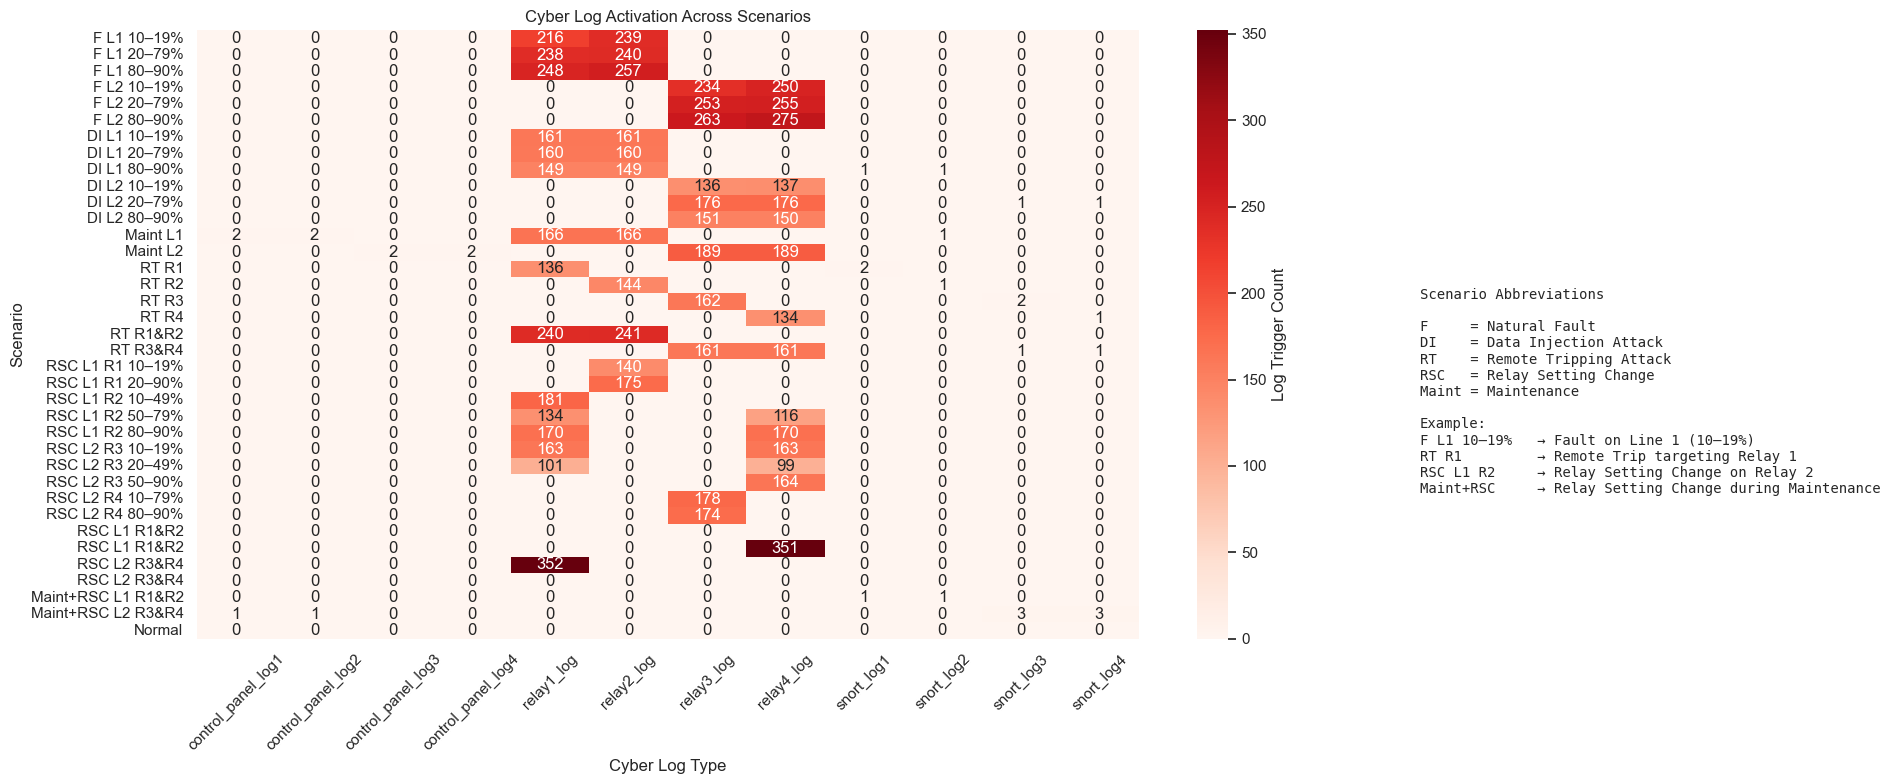

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

log_cols = [
    "control_panel_log1","control_panel_log2","control_panel_log3","control_panel_log4",
    "relay1_log","relay2_log","relay3_log","relay4_log",
    "snort_log1","snort_log2","snort_log3","snort_log4"
]

# ------------------------------------------------------------
# Scenario log table
# ------------------------------------------------------------

scenario_logs = multi_df.groupby("marker")[log_cols].sum()
scenario_logs = scenario_logs.astype(int)

scenario_logs["Scenario"] = scenario_logs.index.map(SCENARIO_LOOKUP)

scenario_logs = scenario_logs[
    ["Scenario"] + log_cols
]

scenario_logs = scenario_logs.sort_index()

display(scenario_logs)

# ------------------------------------------------------------
# Heatmap Data
# ------------------------------------------------------------

heatmap_data = multi_df.groupby("marker")[log_cols].sum()

heatmap_data.index = heatmap_data.index.map(SCENARIO_SHORT)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    cbar_kws={"label": "Log Trigger Count"},
    ax=ax
)

ax.set_xlabel("Cyber Log Type")
ax.set_ylabel("Scenario")
ax.set_title("Cyber Log Activation Across Scenarios")

plt.xticks(rotation=45)

plt.tight_layout()

# ------------------------------------------------------------
# Scenario Legend
# ------------------------------------------------------------

legend_text = """
Scenario Abbreviations

F     = Natural Fault
DI    = Data Injection Attack
RT    = Remote Tripping Attack
RSC   = Relay Setting Change
Maint = Maintenance

Example:
F L1 10–19%   → Fault on Line 1 (10–19%)
RT R1         → Remote Trip targeting Relay 1
RSC L1 R2     → Relay Setting Change on Relay 2
Maint+RSC     → Relay Setting Change during Maintenance
"""

fig.text(
    1.02,
    0.5,
    legend_text,
    fontsize=10,
    va="center",
    family="monospace"
)

plt.show()

Cyber Log Presence by Scenario


,Scenario,total_samples,samples_with_logs,percentage_with_logs
marker,,,,
1,Scenario 1,1643,274,16.676811
2,Scenario 2,1822,246,13.501647
3,Scenario 3,1998,294,14.714715
4,Scenario 4,2968,294,9.905660
5,Scenario 5,3084,261,8.463035
6,Scenario 6,3485,318,9.124821
7,Scenario 7,1423,161,11.314125
8,Scenario 8,1257,160,12.728719
9,Scenario 9,1269,151,11.899133


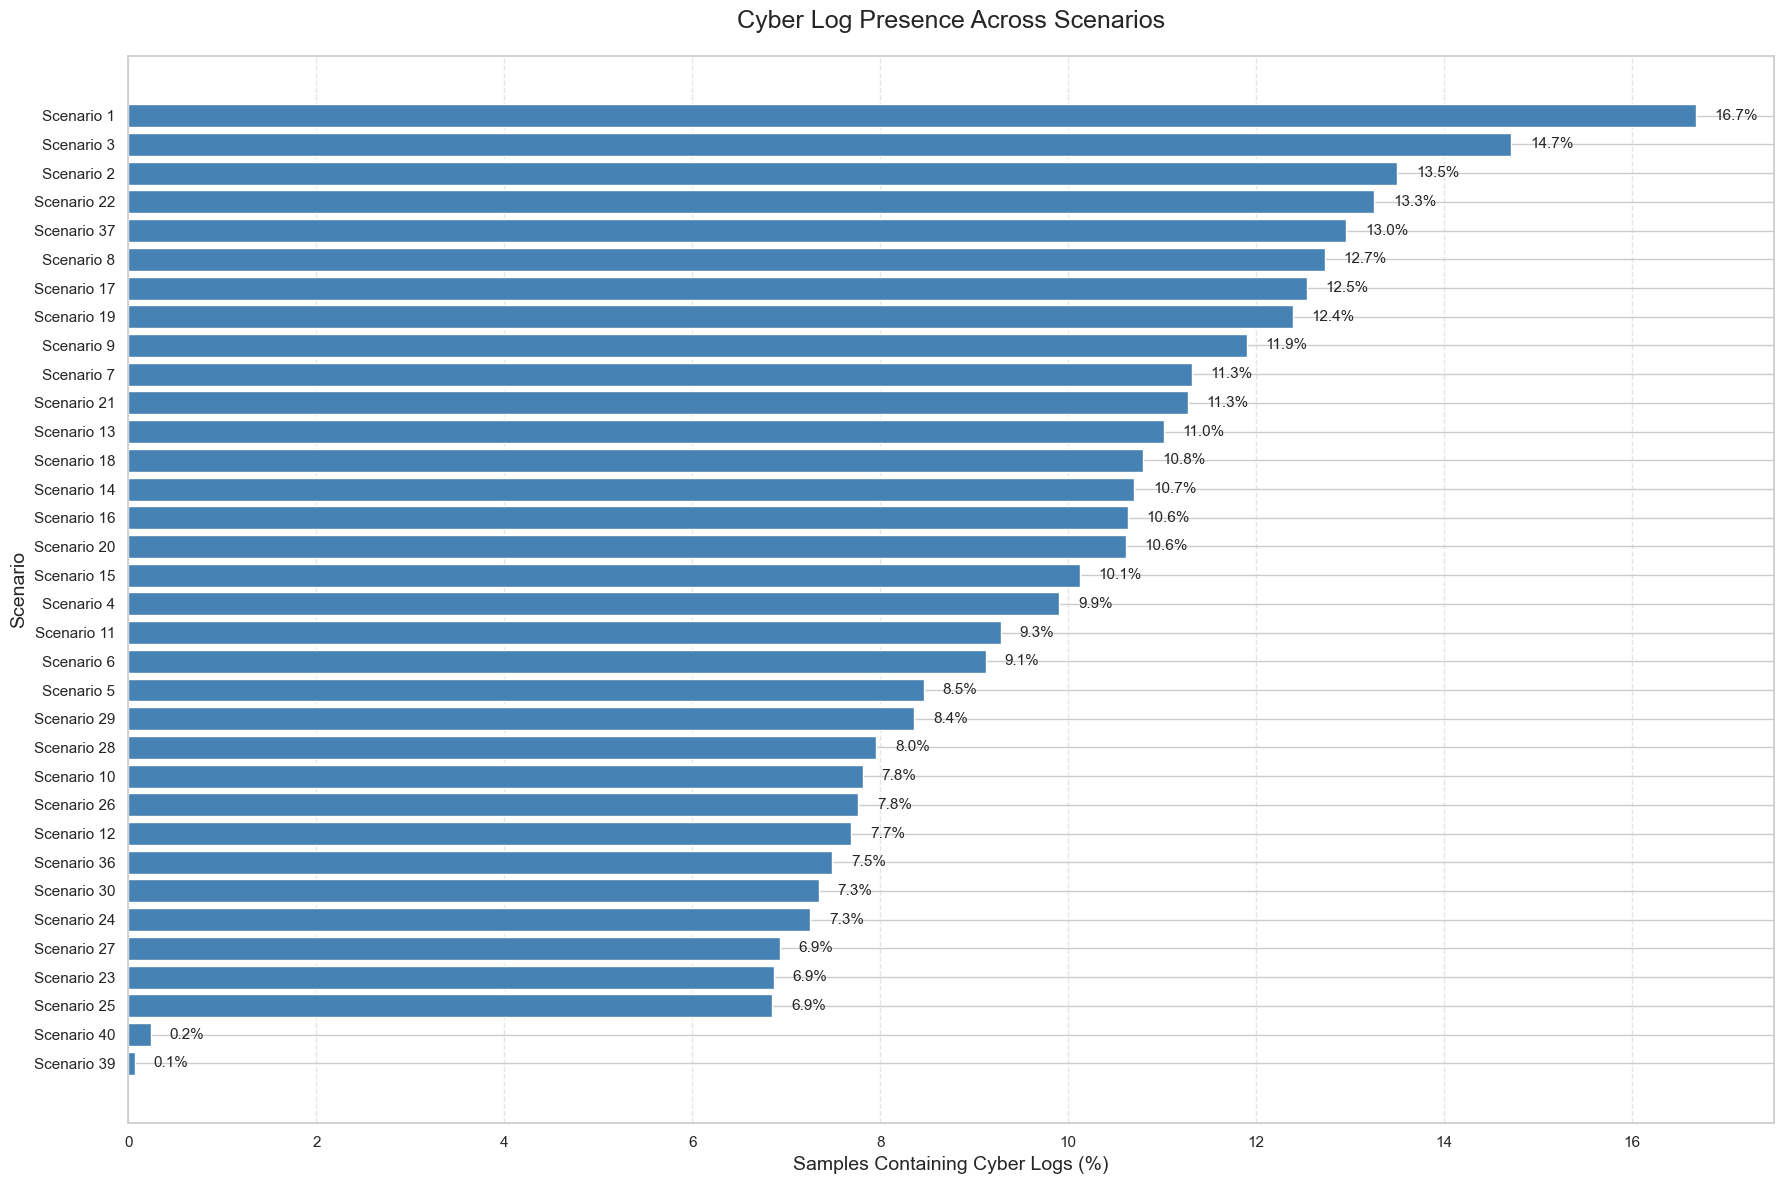

In [49]:
# ============================================================
# Cyber Log Presence by Scenario
# ============================================================

log_cols = [
    "control_panel_log1","control_panel_log2","control_panel_log3","control_panel_log4",
    "relay1_log","relay2_log","relay3_log","relay4_log",
    "snort_log1","snort_log2","snort_log3","snort_log4"
]

# ------------------------------------------------------------
# Flag samples that contain ANY cyber log
# ------------------------------------------------------------
multi_df["has_log"] = (multi_df[log_cols].sum(axis=1) > 0).astype(int)

# ------------------------------------------------------------
# Scenario-level statistics
# ------------------------------------------------------------
scenario_log_summary = multi_df.groupby("marker").agg(
    total_samples=("has_log","count"),
    samples_with_logs=("has_log","sum")
)

scenario_log_summary["percentage_with_logs"] = (
    scenario_log_summary["samples_with_logs"] /
    scenario_log_summary["total_samples"]
) * 100

# Add scenario names
scenario_log_summary["Scenario"] = scenario_log_summary.index.map(SCENARIO_LOOKUP)

# Reorder columns
scenario_log_summary = scenario_log_summary[
    ["Scenario","total_samples","samples_with_logs","percentage_with_logs"]
]

print("Cyber Log Presence by Scenario")
display(scenario_log_summary.sort_index())

plot_df = scenario_log_summary.copy()

# remove scenarios with 0%
plot_df = plot_df[plot_df["percentage_with_logs"] > 0]

# sort
plot_df = plot_df.sort_values("percentage_with_logs")

fig, ax = plt.subplots(figsize=(18,12))

bars = ax.barh(
    plot_df["Scenario"],
    plot_df["percentage_with_logs"],
    color="steelblue"
)

# add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=11
    )

ax.set_xlabel("Samples Containing Cyber Logs (%)", fontsize=14)
ax.set_ylabel("Scenario", fontsize=14)

ax.set_title(
    "Cyber Log Presence Across Scenarios",
    fontsize=18,
    pad=20
)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Aligned size: 37


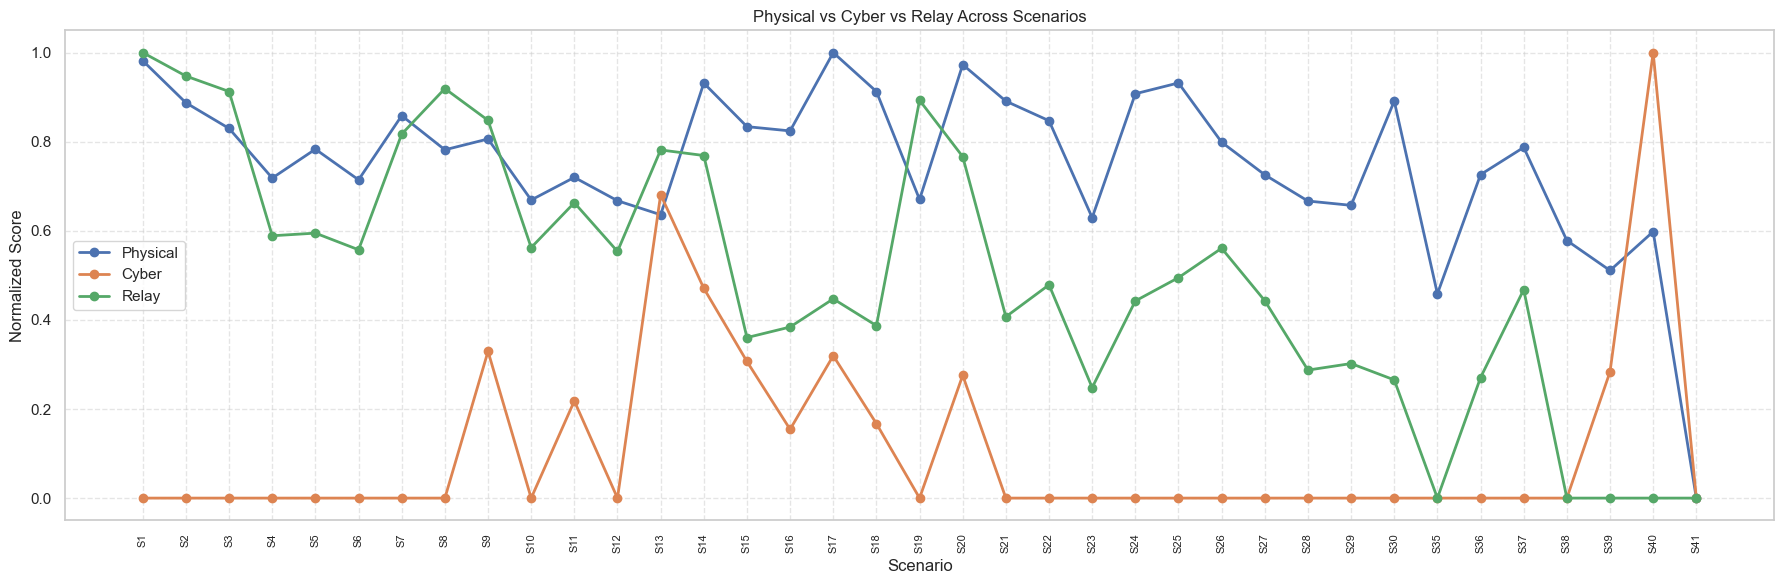

In [78]:
# ============================================================
# FINAL: Physical vs Cyber vs Relay (ROBUST VERSION)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. SAFE INDEX CLEANING (NO ERRORS)
# ------------------------------------------------------------

def clean_index(idx):
    return pd.Index(idx.astype(str).str.extract(r'(\d+)')[0].astype(int))

physical_score.index = clean_index(physical_score.index)
cyber_score.index = clean_index(cyber_score.index)
relay_score.index = clean_index(relay_score.index)

# ------------------------------------------------------------
# 2. ALIGN ALL THREE
# ------------------------------------------------------------

common_idx = (
    physical_score.index
    .intersection(cyber_score.index)
    .intersection(relay_score.index)
)

if len(common_idx) == 0:
    raise ValueError("No overlap — check index formatting")

physical_score = physical_score.loc[common_idx]
cyber_score = cyber_score.loc[common_idx]
relay_score = relay_score.loc[common_idx]

print("Aligned size:", len(common_idx))  # should be 37

# ------------------------------------------------------------
# 3. NORMALIZATION
# ------------------------------------------------------------

def normalize(s):
    if s.max() == s.min():
        return s
    return (s - s.min()) / (s.max() - s.min())

combined_df = pd.DataFrame({
    "Physical": normalize(physical_score),
    "Cyber": normalize(cyber_score),
    "Relay": normalize(relay_score)
})

# ------------------------------------------------------------
# 4. SORT + LABEL
# ------------------------------------------------------------

combined_df = combined_df.sort_index()
combined_df.index = combined_df.index.map(lambda x: f"S{x}")

# ------------------------------------------------------------
# 5. FINAL PLOT (ALL LABELS FIXED)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(18,6))

# IMPORTANT: numeric x-axis
x = range(len(combined_df))

ax.plot(x, combined_df["Physical"], marker='o', linewidth=2, label="Physical")
ax.plot(x, combined_df["Cyber"], marker='o', linewidth=2, label="Cyber")
ax.plot(x, combined_df["Relay"], marker='o', linewidth=2, label="Relay")

ax.set_title("Physical vs Cyber vs Relay Across Scenarios")
ax.set_ylabel("Normalized Score")
ax.set_xlabel("Scenario")

# SHOW ALL SCENARIOS
ax.set_xticks(x)
ax.set_xticklabels(combined_df.index, rotation=90, fontsize=8)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

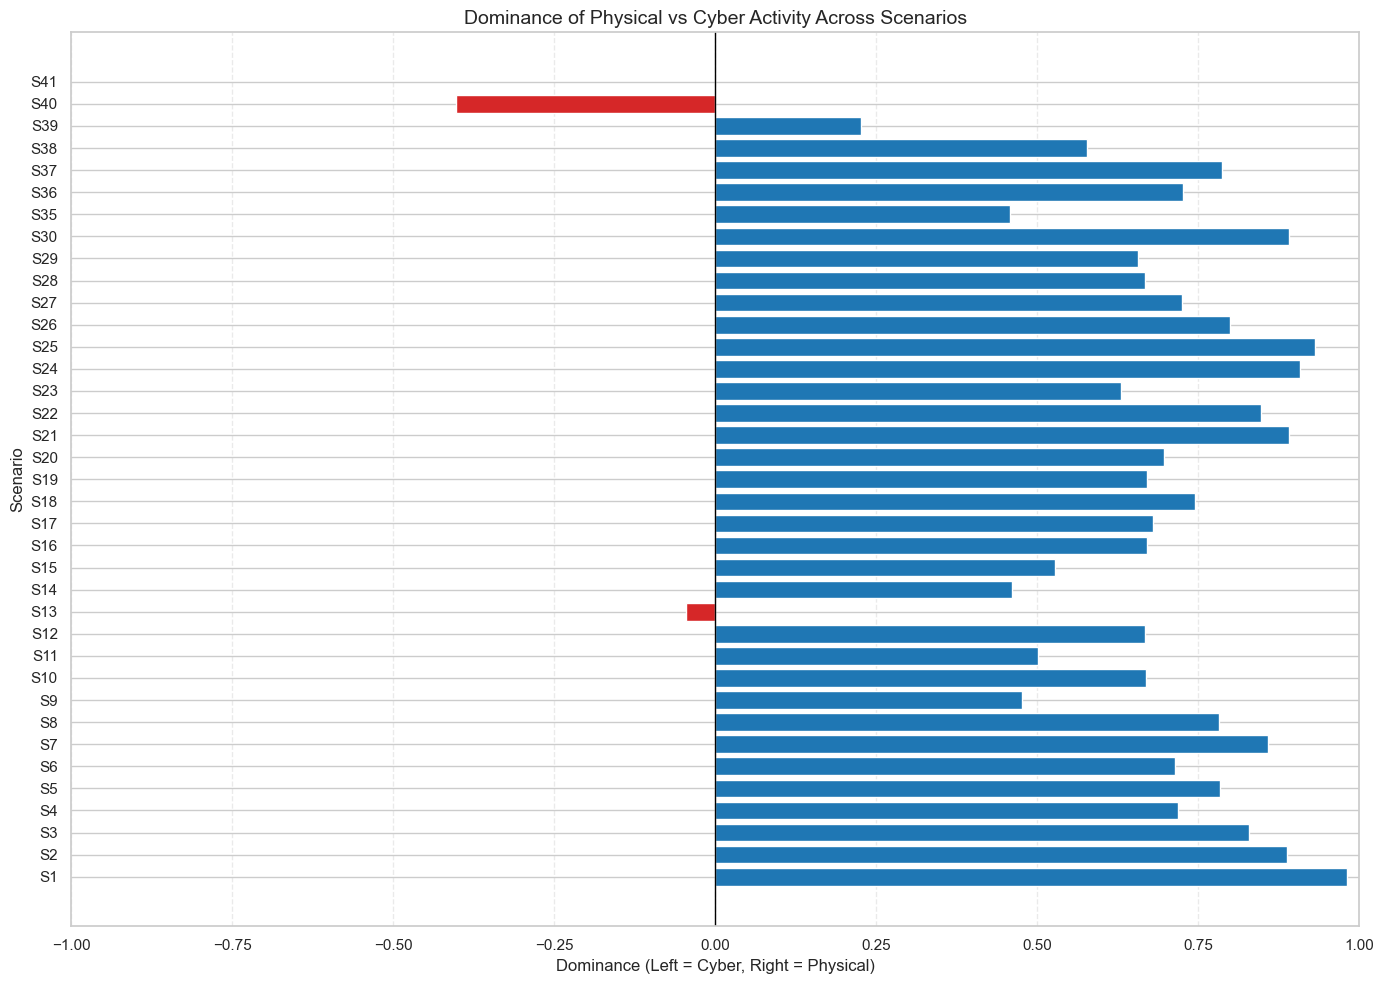

In [83]:
# ============================================================
# DIFFERENCE PLOT (SORTED BY SCENARIO ORDER)
# ============================================================

combined_df["Gap"] = combined_df["Physical"] - combined_df["Cyber"]

# --- Sort by scenario number (S1, S2, ..., S41)
combined_df = combined_df.sort_index(
    key=lambda x: x.str.extract(r'(\d+)')[0].astype(int)
)

gap = combined_df["Gap"]

# Colors
colors = ["#d62728" if v < 0 else "#1f77b4" for v in gap]

fig, ax = plt.subplots(figsize=(14,10))

# Plot (use index directly)
ax.barh(combined_df.index, gap, color=colors)

# Center line
ax.axvline(0, color='black', linewidth=1)

# Labels
ax.set_title("Dominance of Physical vs Cyber Activity Across Scenarios", fontsize=14)
ax.set_xlabel("Dominance (Left = Cyber, Right = Physical)", fontsize=12)
ax.set_ylabel("Scenario", fontsize=12)

# Limits
ax.set_xlim(-1, 1)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Top features: ['R2-PM1:V', 'R2-PM7:V', 'R2-PM2:V', 'R2-PM3:V', 'R3-PM1:V', 'R3-PM2:V', 'R3-PM7:V', 'R3-PM3:V', 'R4-PM2:V', 'R4-PM7:V', 'R1-PM2:V', 'R4-PM3:V', 'R4-PM1:V', 'R1-PM1:V', 'R1-PM3:V']


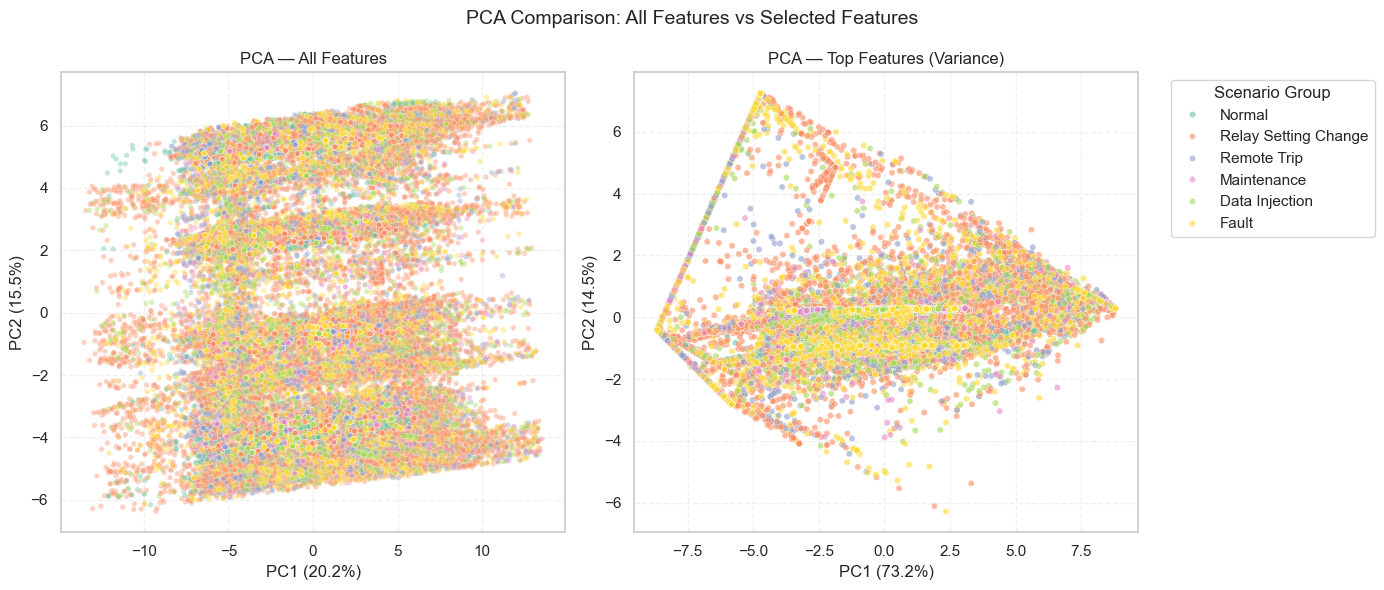

In [91]:
# ============================================================
# FINAL PCA COMPARISON — MULTI (ALL vs AUTO-TOP FEATURES)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------
multi_df = pd.read_csv("../data/merged/multi_class_dataset_clean_FULL.csv")
multi_df.columns = multi_df.columns.str.strip()

# ------------------------------------------------------------
# 2. SCENARIO GROUP
# ------------------------------------------------------------
if "scenario_group" not in multi_df.columns:

    def map_six_groups(s):
        s = int(s)
        if 1 <= s <= 6:
            return "Fault"
        elif 7 <= s <= 12:
            return "Data Injection"
        elif 13 <= s <= 14:
            return "Maintenance"
        elif 15 <= s <= 20:
            return "Remote Trip"
        elif 21 <= s <= 30 or 35 <= s <= 40:
            return "Relay Setting Change"
        elif s == 41:
            return "Normal"
        else:
            return "Unknown"

    multi_df["scenario_group"] = multi_df["marker"].apply(map_six_groups)

y = multi_df["scenario_group"]

# ------------------------------------------------------------
# 3. ALL FEATURES
# ------------------------------------------------------------
numeric_cols = multi_df.select_dtypes(include="number").columns

numeric_cols = [
    c for c in numeric_cols
    if c != "marker" and "log" not in c.lower()
]

X_all = multi_df[numeric_cols]

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

pca_all = PCA(n_components=2, random_state=42)
X_all_pca = pca_all.fit_transform(X_all_scaled)

# ------------------------------------------------------------
# 4. AUTO TOP FEATURES (VARIANCE)
# ------------------------------------------------------------
variances = multi_df[numeric_cols].var().sort_values(ascending=False)

top_features = variances.head(15).index.tolist()

print("Top features:", top_features)

X_top = multi_df[top_features]

scaler_top = StandardScaler()
X_top_scaled = scaler_top.fit_transform(X_top)

pca_top = PCA(n_components=2, random_state=42)
X_top_pca = pca_top.fit_transform(X_top_scaled)

# ------------------------------------------------------------
# 5. PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---- ALL ----
sns.scatterplot(
    x=X_all_pca[:,0],
    y=X_all_pca[:,1],
    hue=y,
    palette="Set2",
    alpha=0.4,
    s=15,
    ax=axes[0],
    legend=False
)

axes[0].set_title("PCA — All Features")
axes[0].set_xlabel(f"PC1 ({pca_all.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_all.explained_variance_ratio_[1]*100:.1f}%)")

# ---- TOP ----
sns.scatterplot(
    x=X_top_pca[:,0],
    y=X_top_pca[:,1],
    hue=y,
    palette="Set2",
    alpha=0.6,
    s=20,
    ax=axes[1]
)

axes[1].set_title("PCA — Top Features (Variance)")
axes[1].set_xlabel(f"PC1 ({pca_top.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_top.explained_variance_ratio_[1]*100:.1f}%)")

axes[1].legend(title="Scenario Group", bbox_to_anchor=(1.05,1))

# style
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("PCA Comparison: All Features vs Selected Features", fontsize=14)

plt.tight_layout()
plt.show()